In [11]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [12]:
class ExamState(TypedDict):
    Syllabus:int
    Revision:int
    PYQ:int
    

In [13]:
def SyllabusCovered(state:ExamState)->ExamState:
    if(state['Syllabus'] > 100) :
        print('Syllabus percent invalid')
    elif(state['Syllabus'] > 80):
        print('Almost done , nice work keep it up.')
    else:
        print('Need to work even more')
    
    return state


In [14]:
def RevisionDone(state:ExamState)->ExamState :
    if(state['Revision'] > 2):
        print('Expected Score 85 %')
    else:
        print("Your current practice won't get you more than 70%")

    return state

In [15]:
def PYQ(state:ExamState)->ExamState :
    if(state['PYQ'] > 5):
        print('Rank under 1000 out of 1 lakh')
    else:
        print('Need to push more PYQ to hold a rank')
    
    return state

In [16]:
graph = StateGraph(ExamState)

# Adding node to the graph
graph.add_node('Syllabus',SyllabusCovered)
graph.add_node('Revision',RevisionDone)
graph.add_node('PYQ',PYQ)

# Adding edges to the graph
graph.add_edge(START,'Syllabus')
graph.add_edge('Syllabus','Revision')
graph.add_edge('Revision','PYQ')
graph.add_edge('PYQ',END)

workflow = graph.compile()


In [17]:
initialState = workflow.invoke({'Syllabus':79,'Revision':3,'PYQ':2})
final_state = workflow.invoke(initialState)

Need to work even more
Expected Score 85 %
Need to push more PYQ to hold a rank
Need to work even more
Expected Score 85 %
Need to push more PYQ to hold a rank


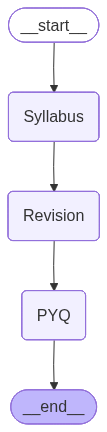

In [18]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())